<a href="https://colab.research.google.com/github/arghyadutta7878-alt/Smart_Chassis_Vibration_Analysis/blob/main/Smart_Chassis_Vibration_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
from google.colab import files

uploaded = files.upload()

Saving Automobile Telematics Dataset.zip to Automobile Telematics Dataset.zip


In [3]:
import os

print("Uploaded files:")

for file in os.listdir("/content"):
    print(file)

Uploaded files:
.config
Automobile Telematics Dataset.zip
sample_data


In [5]:
import zipfile
import os

zip_file = "/content/Automobile Telematics Dataset.zip"

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall("/content/automobile_dataset")

print("Dataset extracted successfully!")

for root, dirs, files_list in os.walk("/content/automobile_dataset"):
    for file in files_list:
        print(os.path.join(root, file))

Dataset extracted successfully!
/content/automobile_dataset/Telematicsdata.csv


In [6]:
import glob

csv_files = glob.glob(
    "/content/automobile_dataset/**/*.csv",
    recursive=True
)

print("CSV files found:")

for file in csv_files:
    print(file)

CSV files found:
/content/automobile_dataset/Telematicsdata.csv


In [8]:
file_path = "/content/automobile_dataset/Telematicsdata.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [9]:
print("Dataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset shape:
(173853, 6)

Column names:
['deviceId', 'timeMili', 'timestamp', 'value', 'variable', 'alarmClass']

First 5 rows:


,deviceId,timeMili,timestamp,value,variable,alarmClass
0,zRYzhAEAHAABAAAKCRtcAAsAtwB1gBAQ,1.597603e+12,2020-08-17 00:00:02.000000,86.0,INTERNAL BATTERY,0
1,zRYzhAEAHAABAAAKCRtcAAsAtwB1gBAQ,1.597603e+12,2020-08-17 00:00:03.000000,"13.330059,74.74467,-12.0",POSITION,0
2,zRYzhAEAHAABAAAKCRtcAAsAtwB1gBAQ,1.597603e+12,2020-08-17 00:00:07.000000,"13.330059,74.74467,-12.0",POSITION,0
3,zRYzhAEAHAABAAAKCRtcAAsAtwB1gBAQ,1.597603e+12,2020-08-17 00:00:10.000000,"13.330059,74.74467,-12.0",POSITION,0
4,zRYzhAEAHAABAAAKCRtcAAsAtwB1gBAQ,1.597603e+12,2020-08-17 00:00:12.000000,96.0,INTERNAL BATTERY,3


In [10]:
print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())


Data types:
deviceId       object
timeMili      float64
timestamp      object
value          object
variable       object
alarmClass      int64
dtype: object

Missing values:
deviceId           0
timeMili      121651
timestamp          0
value              0
variable           0
alarmClass         0
dtype: int64


In [11]:
print("Available sensor variables:")
print(df["variable"].value_counts())

Available sensor variables:
variable
POSITION                                            90355
EXTERNAL BATTERY                                     9625
TOWING                                               6653
IGNITION_STATUS                                      6304
ACCELERATION X                                       5046
ENGINE RPM                                           4514
ACCELERATION Z                                       4447
ACCELERATION Y                                       4322
Vehicle speed                                        3803
CALCULATED ENGINE LOAD                               2290
COMMANDED THROTTLE ACTUATOR                          2289
RELATIVE THROTTLE POSITION                           2162
ABSOLUTE THROTTLE POSITION D                         2117
ABSOLUTE THROTTLE POSITION B                         2116
ABSOLUTE THROTTLE POSITION E                         1956
INTERNAL BATTERY                                     1817
CATALYST TEMPERATURE BANK 1 SENSOR 

In [12]:
variables = df["variable"].unique()

print("Number of different variables:", len(variables))
print("\nVariables:")

for v in variables:
    print(v)

Number of different variables: 52

Variables:
INTERNAL BATTERY
POSITION
EXTERNAL BATTERY
TOWING
IGNITION_STATUS
THROTTLE POSITION
DISTANCE TRAVELED WITH MIL ON
ABSOLUTE THROTTLE POSITION B
ENGINE RPM
AIR INTAKE TEMPERATURE
FUEL SYSTEM STATUS
OBD STANDARDS THIS VEHICLE CONFORMS TO
INTAKE MANIFOLD ABSOLUTE PRESSURE
ACCELERATION Z
IDLING
ACCELERATION Y
ACCELERATION X
ABSOLUTE THROTTLE POSITION E
LONG TERM FUEL TRIM BANK 1
RELATIVE THROTTLE POSITION
ABSOLUTE THROTTLE POSITION D
FUEL AIR COMMANDED EQUIVALENCE RATE
ABSOLUTE LOAD VALUE
CATALYST TEMPERATURE BANK 1 SENSOR 1
ENGINE COOLANT TEMPERATURE
DISTANCE TRAVELED SINCE CODES CLEARED
WARM UPS SINCE CODES CLEARED
OXYGEN SENSOR 2 - B: SHORT TERM FUEL TRIM
RUN TIME SINCE ENGINE START
OXYGEN SENSORS PRESENT IN 2 BANKS
OXYGEN SENSOR 1 - B: SHORT TERM FUEL TRIM
TIMING ADVANCE
HARDWARE STATUS
Vehicle speed
COMMANDED EVAPORATIVE PURGE
MONITOR STATUS THIS DRIVE CYCLE
SHORT TERM FUEL TRIM BANK 1
MONITOR STATUS SINCE DTCS CLEARED
CALCULATED ENGINE LOA

In [13]:

accel_df = df[
    df["variable"].isin([
        "ACCELERATION X",
        "ACCELERATION Y",
        "ACCELERATION Z"
    ])
].copy()

print("Acceleration records:", len(accel_df))

print("\nAcceleration variables:")
print(accel_df["variable"].value_counts())

Acceleration records: 13815

Acceleration variables:
variable
ACCELERATION X    5046
ACCELERATION Z    4447
ACCELERATION Y    4322
Name: count, dtype: int64


In [14]:
print(accel_df[["timestamp", "value", "variable"]].head(20))

                        timestamp       value        variable
13949  2020-08-17 10:38:20.000000         4.0  ACCELERATION Z
13951  2020-08-17 10:38:20.000000   -9.400001  ACCELERATION Y
13952  2020-08-17 10:38:20.000000         0.1  ACCELERATION X
13982  2020-08-17 10:38:25.000000        3.75  ACCELERATION Z
13983  2020-08-17 10:38:25.000000        -8.8  ACCELERATION Y
13984  2020-08-17 10:38:25.000000         0.3  ACCELERATION X
14006  2020-08-17 10:38:32.000000         1.0  ACCELERATION X
14009  2020-08-17 10:38:32.000000   -8.400001  ACCELERATION Y
14014  2020-08-17 10:38:37.000000        -9.0  ACCELERATION Y
14016  2020-08-17 10:38:37.000000         3.5  ACCELERATION Z
14027  2020-08-17 10:38:42.000000  -7.4000006  ACCELERATION Y
14031  2020-08-17 10:38:42.000000         0.6  ACCELERATION X
14032  2020-08-17 10:38:42.000000         5.0  ACCELERATION Z
14035  2020-08-17 10:38:47.000000  0.09999999  ACCELERATION X
14037  2020-08-17 10:38:47.000000        -8.8  ACCELERATION Y
14051  2

In [15]:
accel_df["value"] = pd.to_numeric(
    accel_df["value"],
    errors="coerce"
)

print(accel_df["value"].dtype)
print("Missing acceleration values:", accel_df["value"].isna().sum())

float64
Missing acceleration values: 0


In [16]:
accel_df = accel_df.dropna(subset=["value"]).copy()

print("Remaining records:", len(accel_df))

Remaining records: 13815


In [17]:
acceleration = accel_df.pivot_table(
    index=["deviceId", "timestamp"],
    columns="variable",
    values="value",
    aggfunc="mean"
).reset_index()

print(acceleration.head())

variable                          deviceId                   timestamp  \
0         zRYzhAEAHAABAAAKCRtcAAsAGAB0gBAQ  2020-08-21 14:27:04.000000   
1         zRYzhAEAHAABAAAKCRtcAAsAGAB0gBAQ  2020-08-21 14:27:11.000000   
2         zRYzhAEAHAABAAAKCRtcAAsAGAB0gBAQ  2020-08-21 14:27:16.000000   
3         zRYzhAEAHAABAAAKCRtcAAsAGAB0gBAQ  2020-08-21 14:27:19.000000   
4         zRYzhAEAHAABAAAKCRtcAAsAGAB0gBAQ  2020-08-21 14:27:27.000000   

variable  ACCELERATION X  ACCELERATION Y  ACCELERATION Z  
0                    NaN            -9.0            3.50  
1                    0.6             NaN            3.25  
2                    0.1            -9.0             NaN  
3                    0.1            -9.0            3.25  
4                    NaN             NaN            3.50  


In [18]:
acceleration = acceleration.rename(columns={
    "ACCELERATION X": "accel_x",
    "ACCELERATION Y": "accel_y",
    "ACCELERATION Z": "accel_z"
})

print(acceleration.columns.tolist())

['deviceId', 'timestamp', 'accel_x', 'accel_y', 'accel_z']


In [19]:
print(acceleration[[
    "accel_x",
    "accel_y",
    "accel_z"
]].isnull().sum())

variable
accel_x     666
accel_y    1390
accel_z    1265
dtype: int64


In [20]:
acceleration = acceleration.dropna(
    subset=["accel_x", "accel_y", "accel_z"]
).copy()

print("Final acceleration dataset:", acceleration.shape)

Final acceleration dataset: (3342, 5)


In [21]:
display(acceleration.head(10))

variable,deviceId,timestamp,accel_x,accel_y,accel_z
3,zRYzhAEAHAABAAAKCRtcAAsAGAB0gBAQ,2020-08-21 14:27:19.000000,1.000000e-01,-9.00,3.25
7,zRYzhAEAHAABAAAKCRtcAAsAGAB0gBAQ,2020-08-21 14:37:20.000000,-4.000000e-01,-9.50,5.00
8,zRYzhAEAHAABAAAKCRtcAAsAGAB0gBAQ,2020-08-21 14:37:25.000000,1.600000e+00,-9.25,1.75
9,zRYzhAEAHAABAAAKCRtcAAsAGAB0gBAQ,2020-08-21 14:37:32.000000,1.300000e+00,-9.25,0.00
10,zRYzhAEAHAABAAAKCRtcAAsAGAB0gBAQ,2020-08-21 14:37:37.000000,2.100000e+00,-8.00,2.00
11,zRYzhAEAHAABAAAKCRtcAAsAGAB0gBAQ,2020-08-21 14:37:46.000000,1.600000e+00,-8.75,3.00
13,zRYzhAEAHAABAAAKCRtcAAsAGAB0gBAQ,2020-08-21 14:38:20.000000,-3.000000e-01,-8.75,4.75
14,zRYzhAEAHAABAAAKCRtcAAsAGAB0gBAQ,2020-08-21 14:38:26.000000,-8.999999e-01,-9.50,4.25
15,zRYzhAEAHAABAAAKCRtcAAsAGAB0gBAQ,2020-08-21 14:38:31.000000,-1.100000e+00,-9.50,5.00
18,zRYzhAEAHAABAAAKCRtcAAsAGAB0gBAQ,2020-08-21 14:38:46.000000,9.685755e-08,-8.50,1.75


In [22]:
acceleration["vibration_magnitude"] = np.sqrt(
    acceleration["accel_x"]**2 +
    acceleration["accel_y"]**2 +
    acceleration["accel_z"]**2
)

display(acceleration.head(10))

variable,deviceId,timestamp,accel_x,accel_y,accel_z,vibration_magnitude
3,zRYzhAEAHAABAAAKCRtcAAsAGAB0gBAQ,2020-08-21 14:27:19.000000,1.000000e-01,-9.00,3.25,9.569352
7,zRYzhAEAHAABAAAKCRtcAAsAGAB0gBAQ,2020-08-21 14:37:20.000000,-4.000000e-01,-9.50,5.00,10.742905
8,zRYzhAEAHAABAAAKCRtcAAsAGAB0gBAQ,2020-08-21 14:37:25.000000,1.600000e+00,-9.25,1.75,9.549084
9,zRYzhAEAHAABAAAKCRtcAAsAGAB0gBAQ,2020-08-21 14:37:32.000000,1.300000e+00,-9.25,0.00,9.340905
10,zRYzhAEAHAABAAAKCRtcAAsAGAB0gBAQ,2020-08-21 14:37:37.000000,2.100000e+00,-8.00,2.00,8.509407
11,zRYzhAEAHAABAAAKCRtcAAsAGAB0gBAQ,2020-08-21 14:37:46.000000,1.600000e+00,-8.75,3.00,9.387359
13,zRYzhAEAHAABAAAKCRtcAAsAGAB0gBAQ,2020-08-21 14:38:20.000000,-3.000000e-01,-8.75,4.75,9.960673
14,zRYzhAEAHAABAAAKCRtcAAsAGAB0gBAQ,2020-08-21 14:38:26.000000,-8.999999e-01,-9.50,4.25,10.446172
15,zRYzhAEAHAABAAAKCRtcAAsAGAB0gBAQ,2020-08-21 14:38:31.000000,-1.100000e+00,-9.50,5.00,10.791663
18,zRYzhAEAHAABAAAKCRtcAAsAGAB0gBAQ,2020-08-21 14:38:46.000000,9.685755e-08,-8.50,1.75,8.678277


In [23]:
mean_vibration = acceleration["vibration_magnitude"].mean()
max_vibration = acceleration["vibration_magnitude"].max()
min_vibration = acceleration["vibration_magnitude"].min()
std_vibration = acceleration["vibration_magnitude"].std()

print("===== VIBRATION STATISTICS =====")
print(f"Mean vibration     : {mean_vibration:.3f}")
print(f"Maximum vibration  : {max_vibration:.3f}")
print(f"Minimum vibration  : {min_vibration:.3f}")
print(f"Standard deviation : {std_vibration:.3f}")

===== VIBRATION STATISTICS =====
Mean vibration     : 9.645
Maximum vibration  : 21.628
Minimum vibration  : 3.148
Standard deviation : 1.421


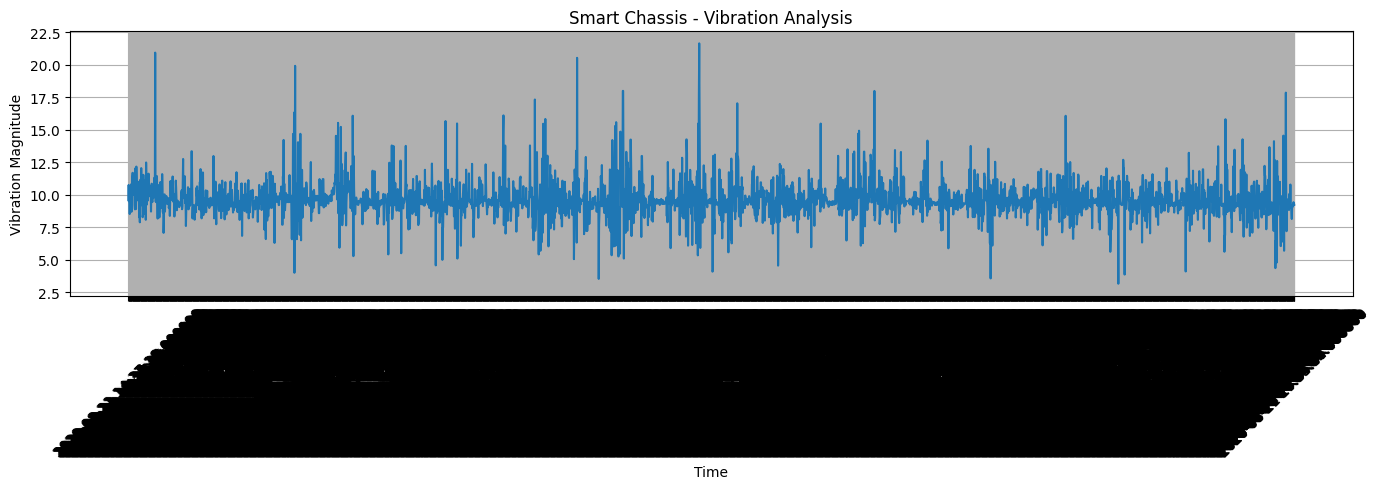

In [24]:
plt.figure(figsize=(14, 5))

plt.plot(
    acceleration["timestamp"],
    acceleration["vibration_magnitude"]
)

plt.xlabel("Time")
plt.ylabel("Vibration Magnitude")
plt.title("Smart Chassis - Vibration Analysis")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

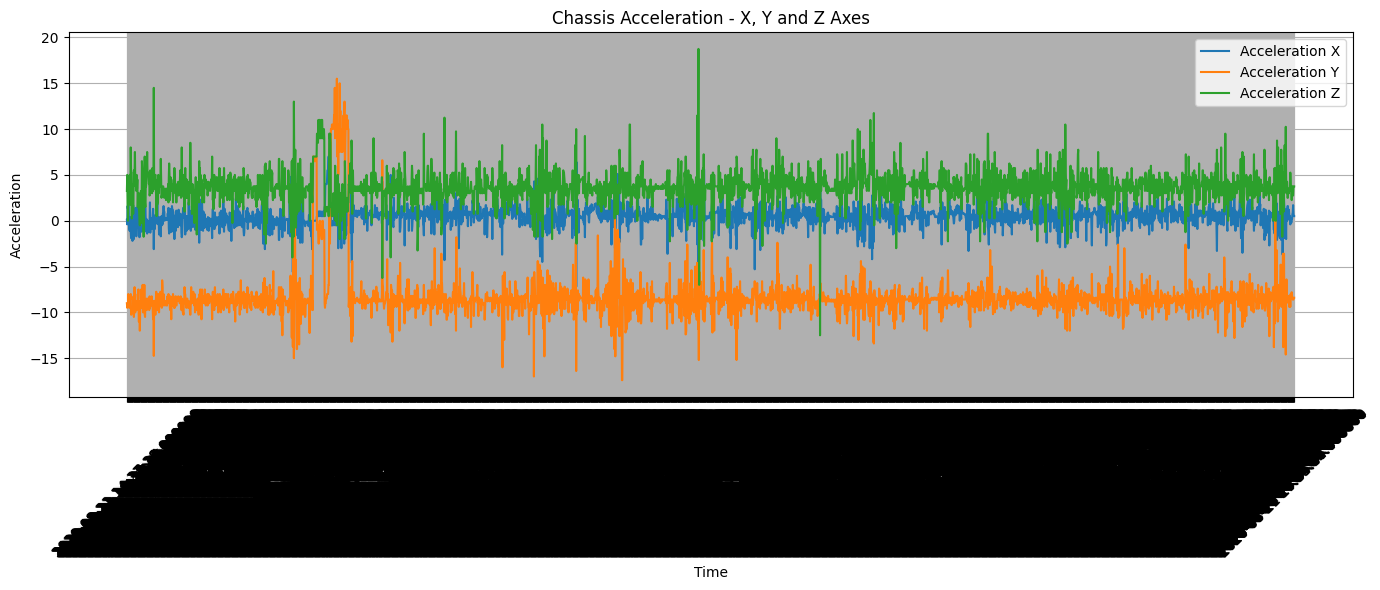

In [25]:
plt.figure(figsize=(14, 6))

plt.plot(
    acceleration["timestamp"],
    acceleration["accel_x"],
    label="Acceleration X"
)

plt.plot(
    acceleration["timestamp"],
    acceleration["accel_y"],
    label="Acceleration Y"
)

plt.plot(
    acceleration["timestamp"],
    acceleration["accel_z"],
    label="Acceleration Z"
)

plt.xlabel("Time")
plt.ylabel("Acceleration")
plt.title("Chassis Acceleration - X, Y and Z Axes")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [26]:
threshold = (
    mean_vibration +
    3 * std_vibration
)

print("Abnormal vibration threshold:", threshold)

Abnormal vibration threshold: 13.909260997284076


In [27]:
acceleration["status"] = np.where(
    acceleration["vibration_magnitude"] > threshold,
    "ABNORMAL",
    "NORMAL"
)

print(acceleration["status"].value_counts())

status
NORMAL      3296
ABNORMAL      46
Name: count, dtype: int64


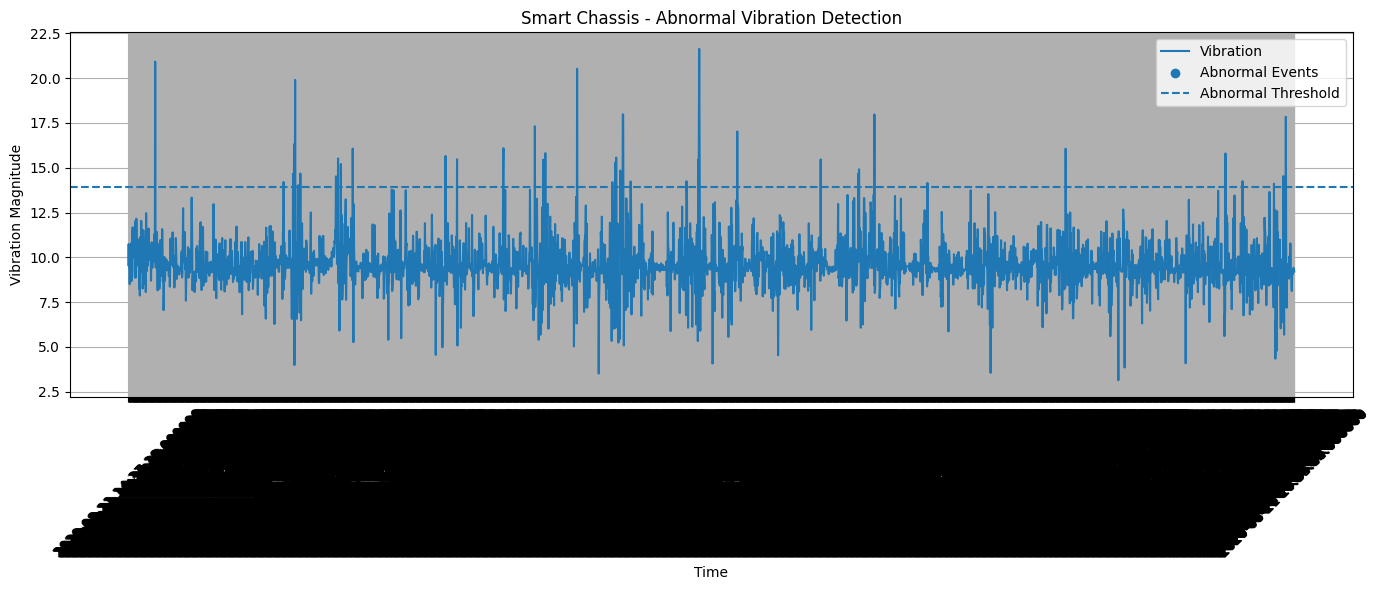

In [28]:
plt.figure(figsize=(14, 6))

plt.plot(
    acceleration["timestamp"],
    acceleration["vibration_magnitude"],
    label="Vibration"
)

abnormal = acceleration[
    acceleration["status"] == "ABNORMAL"
]

plt.scatter(
    abnormal["timestamp"],
    abnormal["vibration_magnitude"],
    label="Abnormal Events"
)

plt.axhline(
    threshold,
    linestyle="--",
    label="Abnormal Threshold"
)

plt.xlabel("Time")
plt.ylabel("Vibration Magnitude")
plt.title("Smart Chassis - Abnormal Vibration Detection")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [29]:
print("Rows:", len(acceleration))
print("Mean:", mean_vibration)
print("Maximum:", max_vibration)
print("Threshold:", threshold)
print(acceleration["status"].value_counts())

Rows: 3342
Mean: 9.644882631059108
Maximum: 21.62804852038207
Threshold: 13.909260997284076
status
NORMAL      3296
ABNORMAL      46
Name: count, dtype: int64


In [30]:
acceleration["timestamp"] = pd.to_datetime(
    acceleration["timestamp"]
)

acceleration = acceleration.sort_values(
    "timestamp"
).reset_index(drop=True)

print(acceleration["timestamp"].head())
print()
print(acceleration["timestamp"].tail())

0   2020-08-17 10:38:20
1   2020-08-17 10:38:25
2   2020-08-17 10:38:42
3   2020-08-17 10:38:52
4   2020-08-17 10:38:57
Name: timestamp, dtype: datetime64[ns]

3337   2020-08-24 12:21:27
3338   2020-08-24 12:21:32
3339   2020-08-24 12:21:37
3340   2020-08-24 12:21:42
3341   2020-08-24 12:22:10
Name: timestamp, dtype: datetime64[ns]


In [31]:
time_diff = acceleration["timestamp"].diff().dt.total_seconds()

print("Sampling interval statistics:")
print(time_diff.describe())

Sampling interval statistics:
count      3341.000000
mean        182.888357
std        4437.464486
min           1.000000
25%           5.000000
50%           5.000000
75%          10.000000
max      228867.000000
Name: timestamp, dtype: float64


In [32]:
print("\nMost common sampling intervals:")
print(time_diff.round(2).value_counts().head(10))


Most common sampling intervals:
timestamp
5.0     1630
10.0     320
2.0      114
6.0      105
3.0      105
7.0      100
15.0      88
60.0      86
4.0       64
11.0      45
Name: count, dtype: int64


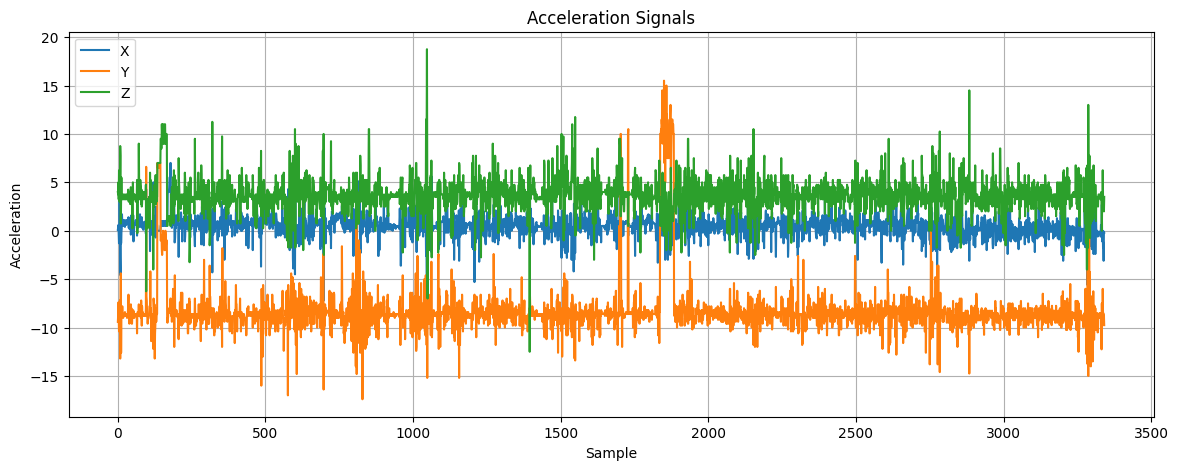

In [33]:
plt.figure(figsize=(14, 5))

plt.plot(
    acceleration.index,
    acceleration["accel_x"],
    label="X"
)

plt.plot(
    acceleration.index,
    acceleration["accel_y"],
    label="Y"
)

plt.plot(
    acceleration.index,
    acceleration["accel_z"],
    label="Z"
)

plt.xlabel("Sample")
plt.ylabel("Acceleration")
plt.title("Acceleration Signals")
plt.legend()
plt.grid(True)

plt.show()

In [34]:
signal = (
    acceleration["vibration_magnitude"]
    - acceleration["vibration_magnitude"].mean()
)

print("Signal mean:", signal.mean())

Signal mean: 1.171481290855222e-15


In [35]:
abnormal_events = acceleration[
    acceleration["status"] == "ABNORMAL"
]

display(
    abnormal_events[
        [
            "timestamp",
            "accel_x",
            "accel_y",
            "accel_z",
            "vibration_magnitude",
            "status"
        ]
    ].head(20)
)

variable,timestamp,accel_x,accel_y,accel_z,vibration_magnitude,status
8,2020-08-17 10:39:45,-2.7,-13.200000,8.75,16.065258,ABNORMAL
320,2020-08-17 14:50:30,-4.3,-9.999999,11.25,15.654152,ABNORMAL
353,2020-08-17 15:24:57,-0.5,-12.000001,9.75,15.469729,ABNORMAL
485,2020-08-17 16:09:02,-3.7,-11.599998,8.25,14.707564,ABNORMAL
486,2020-08-17 16:09:07,0.8,-16.000002,1.50,16.090061,ABNORMAL
576,2020-08-17 16:27:51,-0.3,-17.000000,3.25,17.310474,ABNORMAL
600,2020-08-17 16:30:02,-4.5,-10.400000,10.50,15.448625,ABNORMAL
606,2020-08-17 16:30:42,-0.9,-14.799999,5.50,15.814549,ABNORMAL
697,2020-08-17 16:50:28,-7.2,-16.400000,10.00,20.513410,ABNORMAL
798,2020-08-17 17:15:04,-2.6,-12.600001,6.00,14.195775,ABNORMAL


In [36]:
total = len(acceleration)
abnormal_count = len(abnormal_events)

abnormal_percentage = (
    abnormal_count / total
) * 100

print(f"Total records       : {total}")
print(f"Normal records      : {total - abnormal_count}")
print(f"Abnormal records    : {abnormal_count}")
print(f"Abnormal percentage : {abnormal_percentage:.2f}%")

Total records       : 3342
Normal records      : 3296
Abnormal records    : 46
Abnormal percentage : 1.38%


In [37]:
print(time_diff.describe())
print(time_diff.round(2).value_counts().head(10))

count      3341.000000
mean        182.888357
std        4437.464486
min           1.000000
25%           5.000000
50%           5.000000
75%          10.000000
max      228867.000000
Name: timestamp, dtype: float64
timestamp
5.0     1630
10.0     320
2.0      114
6.0      105
3.0      105
7.0      100
15.0      88
60.0      86
4.0       64
11.0      45
Name: count, dtype: int64


In [38]:
# Calculate time difference in seconds
acceleration["time_diff"] = (
    acceleration["timestamp"]
    .diff()
    .dt.total_seconds()
)

# Show the most common intervals
print("Most common time intervals:")
print(
    acceleration["time_diff"]
    .round(2)
    .value_counts()
    .head(15)
)

Most common time intervals:
time_diff
5.0     1630
10.0     320
2.0      114
6.0      105
3.0      105
7.0      100
15.0      88
60.0      86
4.0       64
11.0      45
1.0       41
9.0       32
20.0      32
8.0       31
12.0      28
Name: count, dtype: int64


In [39]:
# Use timestamp as index
ts = acceleration.set_index("timestamp").copy()

# Keep only the vibration magnitude
vibration_ts = ts[["vibration_magnitude"]].copy()

# Resample every 5 seconds
vibration_5s = vibration_ts.resample("5s").mean()

# Fill small gaps using interpolation
vibration_5s["vibration_magnitude"] = (
    vibration_5s["vibration_magnitude"]
    .interpolate(limit=10)
)

# Remove remaining missing values
vibration_5s = vibration_5s.dropna()

print("5-second samples:", len(vibration_5s))
display(vibration_5s.head())

5-second samples: 8243


variable,vibration_magnitude
timestamp,
2020-08-17 10:38:20,10.216165
2020-08-17 10:38:25,9.570397
2020-08-17 10:38:30,9.363924
2020-08-17 10:38:35,9.157451
2020-08-17 10:38:40,8.950978


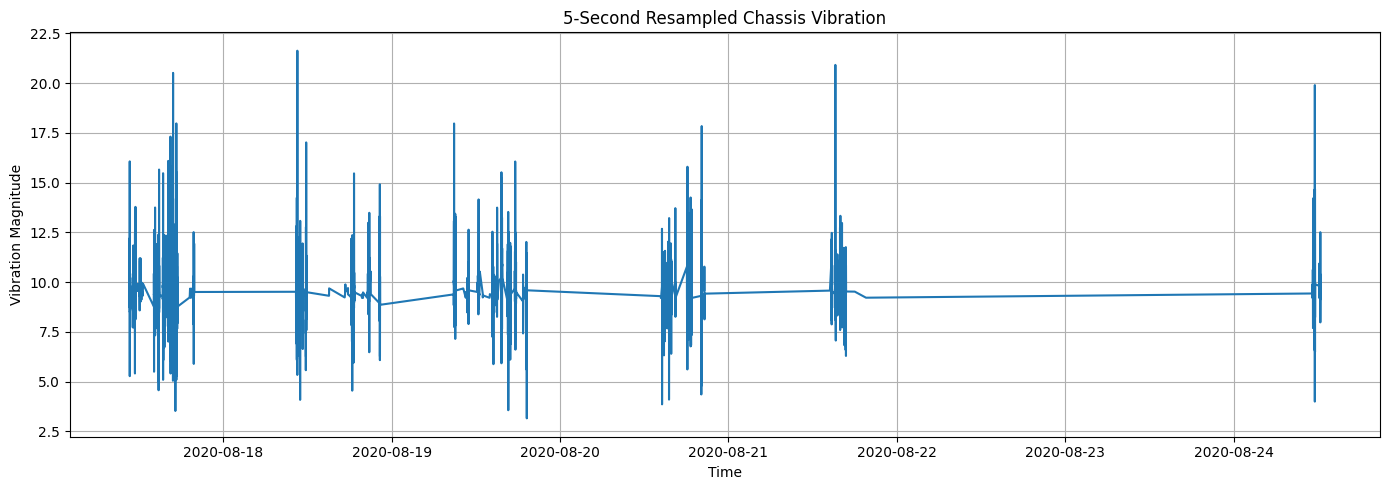

In [40]:
plt.figure(figsize=(14, 5))

plt.plot(
    vibration_5s.index,
    vibration_5s["vibration_magnitude"]
)

plt.xlabel("Time")
plt.ylabel("Vibration Magnitude")
plt.title("5-Second Resampled Chassis Vibration")
plt.grid(True)

plt.tight_layout()
plt.show()

In [41]:
from scipy.fft import fft, fftfreq

signal = vibration_5s["vibration_magnitude"].values

# Remove mean
signal = signal - np.mean(signal)

N = len(signal)

sampling_interval = 5.0
sampling_frequency = 1 / sampling_interval

# FFT
fft_values = fft(signal)

frequencies = fftfreq(
    N,
    d=sampling_interval
)

# Positive frequencies only
positive = frequencies >= 0

frequencies_positive = frequencies[positive]
amplitude_positive = np.abs(fft_values[positive])

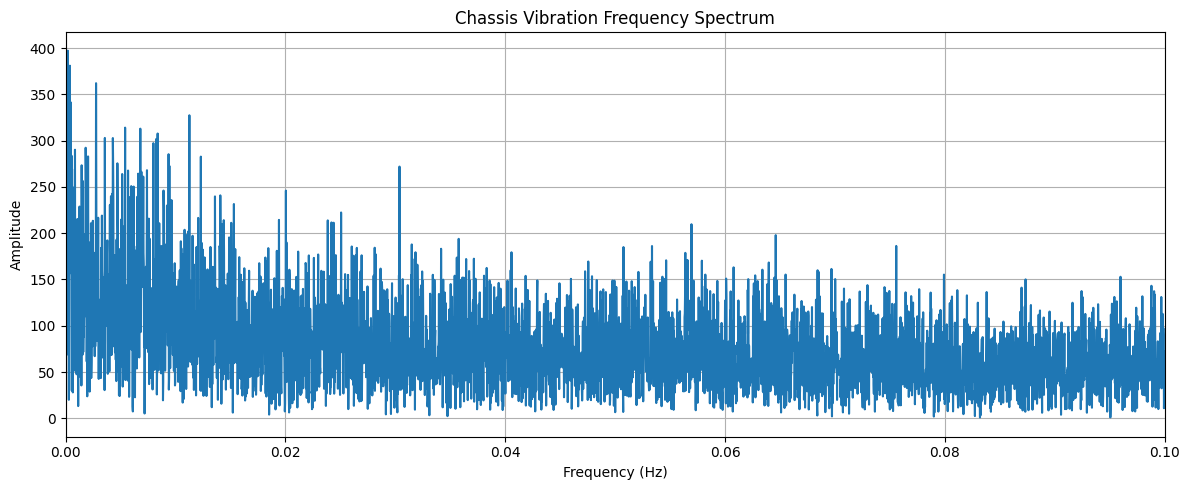

In [42]:
plt.figure(figsize=(12, 5))

plt.plot(
    frequencies_positive,
    amplitude_positive
)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Chassis Vibration Frequency Spectrum")
plt.grid(True)

plt.xlim(0, 0.1)

plt.tight_layout()
plt.show()

In [43]:
# Ignore the 0 Hz component
dominant_index = np.argmax(
    amplitude_positive[1:]
) + 1

dominant_frequency = frequencies_positive[
    dominant_index
]

dominant_amplitude = amplitude_positive[
    dominant_index
]

print("===== FREQUENCY ANALYSIS =====")
print(f"Sampling frequency : {sampling_frequency:.3f} Hz")
print(f"Dominant frequency : {dominant_frequency:.5f} Hz")
print(f"Dominant amplitude : {dominant_amplitude:.3f}")

===== FREQUENCY ANALYSIS =====
Sampling frequency : 0.200 Hz
Dominant frequency : 0.00019 Hz
Dominant amplitude : 397.158


In [44]:
total_records = len(acceleration)
normal_records = (acceleration["status"] == "NORMAL").sum()
abnormal_records = (acceleration["status"] == "ABNORMAL").sum()

abnormal_percentage = (
    abnormal_records / total_records
) * 100

print("=" * 50)
print("     SMART CHASSIS VIBRATION ANALYSIS")
print("=" * 50)

print(f"Total acceleration records : {total_records}")
print(f"Normal records             : {normal_records}")
print(f"Abnormal records           : {abnormal_records}")
print(f"Abnormal percentage        : {abnormal_percentage:.2f}%")

print(f"\nMean vibration             : {mean_vibration:.3f}")
print(f"Maximum vibration          : {max_vibration:.3f}")
print(f"Detection threshold        : {threshold:.3f}")

print(f"\nDominant frequency         : {dominant_frequency:.5f} Hz")

print("\nFINAL STATUS:")

if abnormal_percentage > 1:
    print("⚠ ABNORMAL VIBRATION PATTERN DETECTED")
    print("Potential structural abnormality requires inspection.")
else:
    print("✓ VIBRATION WITHIN NORMAL RANGE")

     SMART CHASSIS VIBRATION ANALYSIS
Total acceleration records : 3342
Normal records             : 3296
Abnormal records           : 46
Abnormal percentage        : 1.38%

Mean vibration             : 9.645
Maximum vibration          : 21.628
Detection threshold        : 13.909

Dominant frequency         : 0.00019 Hz

FINAL STATUS:
⚠ ABNORMAL VIBRATION PATTERN DETECTED
Potential structural abnormality requires inspection.


In [45]:
import joblib

model = {
    "mean_vibration": mean_vibration,
    "std_vibration": std_vibration,
    "threshold": threshold
}

joblib.dump(model, "smart_chassis_vibration_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [46]:
acceleration.to_csv(
    "smart_chassis_processed_data.csv",
    index=False
)

files.download("smart_chassis_processed_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>